# Cross-dataset: Laboro vs tomatOD



1. How does the same model do on each dataset on its own?
2. What happens if I train on one and test on the other?
3. Does training on both help, or blur?


## Data

| | Laboro Tomato | tomatOD |
|---|---|---|
| images | 804 | 277 |
| split | 643 / 161 | 222 / 55 |
| boxes | 9 777 | 2 421 |
| classes | 6 (size x ripeness) | 3 |
| where | farm, Japan, two cameras | greenhouse, Greece |

Both CC BY-NC-SA 4.0, neither committed here - `fetch.py` pulls them.

I use each dataset's own split. Making my own would put a choice of mine into the
comparison, and both publish one. Side effect: the mix can't leak, since a frame
belongs to one dataset and one split.

Laboro has 6 classes, tomatOD has 3 with different names, so nothing is
comparable until both speak the same language. `taxonomy.py` maps them onto
`green / half_ripened / fully_ripened` and throws away Laboro's size split, which
the counting never used. Mapping is by class name; `"semi-ripe"` and `"unripe"`
both contain `"ripe"`, so those rules have to be checked first.

Note: the 6-class baseline from section 1 (0.706) and `laboro3` below are not
comparable. Three classes is an easier problem.

## Two things that bit me

`tomatOD_test.json` has one category record, `{'id': 1, 'name': ['unripe',
'semi-ripe', 'fully-ripe']}` - name is a list - while the annotations in the same
file use category_id 1, 2 and 3. The obvious converter reads categories per split
and silently puts the whole test set in one class. I take the id->name map from
train.

Their README says 2 418 boxes, the files hold 2 421 (+1 unripe in train, +2 semi
in test). So `prepare.py` checks against the README numbers and records the
difference instead of checking the json against itself.

Laboro converted exactly to its published counts: 643/7781 and 161/1996.

## Setup

In [1]:
import json, platform, sys
from pathlib import Path

import torch, ultralytics

ROOT = Path.cwd().parent if Path.cwd().name == "cross_dataset" else Path.cwd()
print(sys.version.split()[0], platform.platform())
print("torch", torch.__version__, "| MPS", torch.backends.mps.is_available())
print("ultralytics", ultralytics.__version__)

3.13.0 macOS-26.2-arm64-arm-64bit-Mach-O
torch 2.13.0 | MPS True
ultralytics 8.4.115


Same protocol for all three runs, since the protocol is the comparison:
YOLO11n detect, 60 epochs, imgsz 640, batch 16, AdamW (auto), seed 0, MPS.

`patience=0` on purpose. With early stopping the three runs would end at
different epochs and I'd be comparing training length as well as training data.

## Matrix

In [2]:
matrix = json.loads((ROOT / "runs" / "cross_matrix.json").read_text())

MODELS = ["laboro3", "tomatod", "mix"]
VALS = ["laboro3", "tomatod"]
cell = {(r["model"], r["val"]): r for r in matrix}

def table(metric, fmt="{:.3f}"):
    rows = ["| model \\ val | " + " | ".join(VALS) + " |",
            "|---|" + "|".join([":--:"] * len(VALS)) + "|"]
    for m in MODELS:
        cells = []
        for v in VALS:
            r = cell[(m, v)]
            x = fmt.format(r["counting"]["overall"] if metric == "counting" else r[metric])
            cells.append(f"**{x}**" if m == v else x)
        rows.append(f"| {m} | " + " | ".join(cells) + " |")
    return "\n".join(rows)

from IPython.display import Markdown, display
display(Markdown("mAP50-95 (bold = in-domain)\n\n" + table("map50_95")))
display(Markdown("counting-MAE per image\n\n" + table("counting", "{:.2f}")))

mAP50-95 (bold = in-domain)

| model \ val | laboro3 | tomatod |
|---|:--:|:--:|
| laboro3 | **0.698** | 0.389 |
| tomatod | 0.308 | **0.563** |
| mix | 0.704 | 0.546 |

counting-MAE per image

| model \ val | laboro3 | tomatod |
|---|:--:|:--:|
| laboro3 | **1.25** | 3.29 |
| tomatod | 2.14 | **1.00** |
| mix | 1.14 | 1.24 |

In [3]:
print(f"{'model':<9}{'val':<9}{'mAP50-95':>9}{'mAP50':>8}{'P':>7}{'R':>7}{'MAE':>7}   per stage")
for r in matrix:
    per = "  ".join(f"{k.split('_')[0]}={v:.2f}" for k, v in r["counting"]["per_stage"].items())
    print(f"{r['model']:<9}{r['val']:<9}{r['map50_95']:>9.3f}{r['map50']:>8.3f}"
          f"{r['precision']:>7.3f}{r['recall']:>7.3f}{r['counting']['overall']:>7.2f}   {per}")

model    val       mAP50-95   mAP50      P      R    MAE   per stage
laboro3  laboro3      0.698   0.844  0.812  0.779   1.25   green=1.79  half=0.89  fully=1.09
laboro3  tomatod      0.389   0.661  0.734  0.656   3.29   green=3.84  half=4.95  fully=1.09
tomatod  laboro3      0.308   0.485  0.610  0.484   2.14   green=3.96  half=1.15  fully=1.33
tomatod  tomatod      0.563   0.852  0.727  0.879   1.00   green=1.51  half=0.78  fully=0.71
mix      laboro3      0.704   0.849  0.835  0.774   1.14   green=1.75  half=0.92  fully=0.75
mix      tomatod      0.546   0.829  0.744  0.815   1.24   green=1.96  half=0.85  fully=0.91


Diagonal answers Q1, off-diagonal answers Q2, bottom row against the
diagonal answers Q3.

`half` is the worst class on both datasets (0.666 on Laboro, 0.510 on tomatOD).
Two independent annotation teams, and the middle of the scale is the hard part
for both.

## Which direction is the error?

MAE says how far off a count is, not which way. That turns out to matter: the two
cross cells are wrong for completely different reasons.

In [4]:
for val in VALS:
    print(f"#### val = {val}")
    print(f"{'model':>9}{'stage':>8}{'GT':>7}{'pred':>7}{'bias':>9}{'MAE':>7}")
    for m in MODELS:
        cnt = cell[(m, val)]["counting"]
        for s in ["green", "half_ripened", "fully_ripened"]:
            gt, pr = cnt["gt_totals"].get(s, 0), cnt["pred_totals"].get(s, 0)
            bias = (pr - gt) / gt * 100 if gt else 0
            print(f"{m + ('*' if m == val else ''):>9}{s.split('_')[0]:>8}"
                  f"{gt:>7}{pr:>7}{bias:>+8.0f}%{cnt['per_stage'][s]:>7.2f}")
        print()

#### val = laboro3
    model   stage     GT   pred     bias    MAE
 laboro3*   green   1316   1452     +10%   1.79
 laboro3*    half    339    408     +20%   0.89
 laboro3*   fully    341    490     +44%   1.09

  tomatod   green   1316    799     -39%   3.96
  tomatod    half    339    234     -31%   1.15
  tomatod   fully    341    267     -22%   1.33

      mix   green   1316   1424      +8%   1.75
      mix    half    339    403     +19%   0.92
      mix   fully    341    404     +18%   0.75

#### val = tomatod
    model   stage     GT   pred     bias    MAE
  laboro3   green    292    501     +72%   3.84
  laboro3    half     77    349    +353%   4.95
  laboro3   fully     99     49     -51%   1.09

 tomatod*   green    292    369     +26%   1.51
 tomatod*    half     77    106     +38%   0.78
 tomatod*   fully     99    112     +13%   0.71

      mix   green    292    398     +36%   1.96
      mix    half     77    114     +48%   0.85
      mix   fully     99    135     +36%   0.

`tomatod` on Laboro undercounts everything by 22-39% and recall drops
0.88 -> 0.48. It just isn't finding the fruit.

`laboro3` on tomatOD is a different animal. Recall holds up (0.78 -> 0.66), it
over-predicts green (+72%) and half (+353%), and then `fully` goes the other way:
**-51%**. One class collapses while everything else inflates.

So it finds the tomatoes and disagrees about what stage they're at.

## Where does each dataset draw the line?

If the two disagree about ripeness, that should be visible in the labels
themselves, without any model involved.

Every annotated box, cropped to its middle, reduced to its median a\* in CIELAB
(the green-to-red axis, which is what ripening moves). a\* also shifts with white
balance, so each box is also measured against the median a\* of its own image -
mostly leaves, so it works as a per-image green reference.

In [5]:
colour = json.loads((ROOT / "runs" / "colour_stages" / "colour_stages.json").read_text())

for key, label in (("a", "raw"), ("a_rel", "vs image background")):
    b = colour[key]
    print(f"### {label}")
    for ds, st in b["stats"].items():
        print("  " + f"{ds:<9}" + "  ".join(f"{s.split('_')[0]}={v['median']:+.1f}"
                                            for s, v in st.items() if v))
    for ds, t in b["thresholds"].items():
        print(f"  {ds:<9} cuts at {t['green_half']:+.1f} and {t['half_fully']:+.1f}"
              f"  (recovers {t['balanced_accuracy']:.0%} of its own labels)")
    for pair, res in b["cross"].items():
        per = "  ".join(f"{s.split('_')[0]} {v:.0%}"
                        for s, v in res["per_stage_changed"].items() if v is not None)
        print(f"  {pair}: {res['changed']:.0%} of labels change   ({per})")
    print()

### raw
  laboro3  green=-17.7  half=+10.0  fully=+33.0
  tomatod  green=-7.8  half=+2.2  fully=+9.8
  laboro3   cuts at -10.1 and +23.9  (recovers 82% of its own labels)
  tomatod   cuts at -3.4 and +6.3  (recovers 78% of its own labels)
  laboro3->tomatod: 64% of labels change   (green 71%  half 1%  fully 97%)
  tomatod->laboro3: 16% of labels change   (green 1%  half 77%  fully 9%)

### vs image background
  laboro3  green=-5.6  half=+18.9  fully=+41.7
  tomatod  green=-4.2  half=+6.6  fully=+13.6
  laboro3   cuts at +3.2 and +31.0  (recovers 76% of its own labels)
  tomatod   cuts at -0.1 and +11.7  (recovers 78% of its own labels)
  laboro3->tomatod: 22% of labels change   (green 1%  half 25%  fully 98%)
  tomatod->laboro3: 27% of labels change   (green 20%  half 75%  fully 7%)



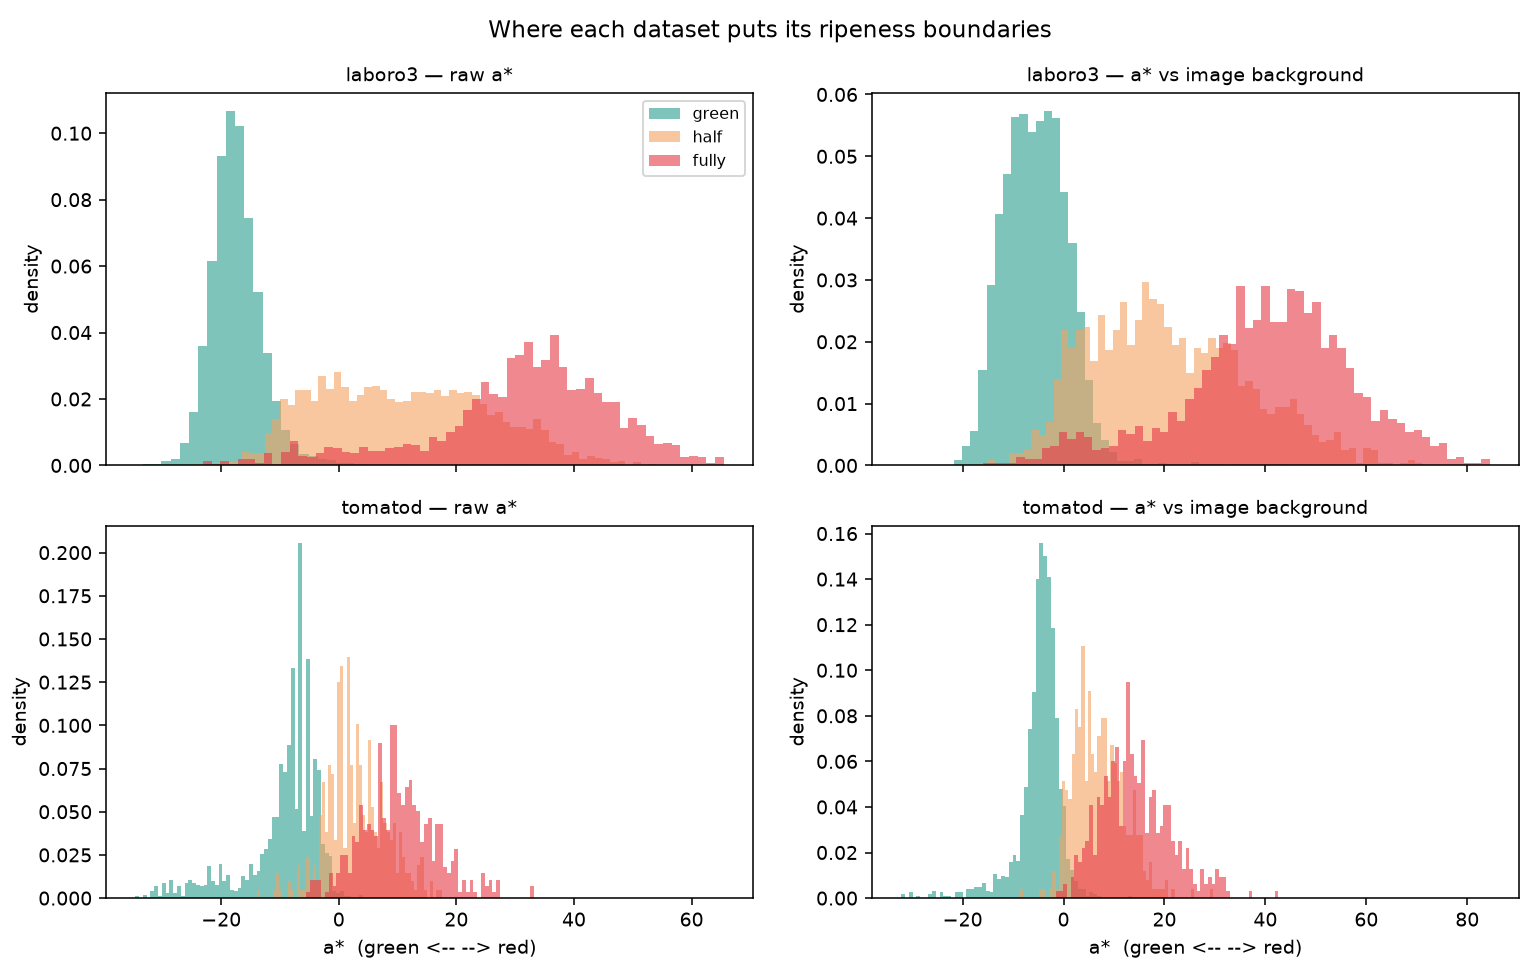

In [6]:
from IPython.display import Image
Image(str(ROOT / "runs" / "colour_stages" / "colour_stages.png"))

Green lines up between the two (-5.6 and -4.2). Above that they split:
Laboro's half sits at +18.9 against tomatOD's +6.6, fully at +41.7 against +13.6.
The cut for "fully ripe" is +31.0 for Laboro and +11.7 for tomatOD.

Swap the boundaries and **98% of what tomatOD calls fully ripe (406 of 431) lands
in Laboro's half band**. The other way, 68% of Laboro's half would be fully ripe.

The white-balance control does its job: on raw a\* the two greens are 10 points
apart, and that gap mostly disappears once each box is measured against its own
image. The half/fully gap doesn't disappear, it gets bigger. So this is the
annotation, not the camera.

Which is exactly the -51% on `fully` from the previous section, seen from the
other side.

## The mix

I expected this to go badly. The mix trains on contradictory labels: a fruit at
a\* +15 is `fully` in tomatOD and `half` in Laboro, and no model can satisfy both.
I wrote down beforehand that it should lose accuracy at the half/fully boundary in
both domains.

It didn't.

| | Laboro | tomatOD |
|---|:--:|:--:|
| specialist mAP50-95 | 0.698 | 0.563 |
| mix | **0.704** | 0.546 |
| specialist counting-MAE | 1.25 | **1.00** |
| mix | **1.14** | 1.24 |

It matches the Laboro specialist on Laboro, costs 0.017 mAP on tomatOD, and the
cross cells go 0.308 -> 0.704 and 0.389 -> 0.546.

The interesting part is the bias table above. `laboro3` puts tomatOD's `fully` at
-51%; the mix puts it at +36%, same side as tomatOD's own specialist (+13%) -
even though Laboro supplies 80% of the boxes. The mix did not inherit the bias.

My guess at why: the domains look different. Greek greenhouse, Japanese farm,
different cameras, framing, fruit density. The network never has to commit to one
rule "ripe starts at a\* = X". It can learn "in pictures like this, ripe starts
here; in pictures like that, there". Once the disagreement is predictable from
the image it stops being a contradiction.

## What I take from this

Answers to the three questions: Laboro 0.699 and tomatOD 0.563 on their own;
transfer costs about half the mAP and triples the counting error, but for
different reasons in each direction; and mixing helps rather than blurs - one
model at specialist level on both, much better under transfer.

The part that matters for the thesis is the one I got wrong. Label noise that
**correlates with a domain the model can recognise is nearly free** - the model
picks up the annotator's convention along with the domain, and the labels aren't
noisy to it, they're conditional. What should hurt is noise that can't be
recovered from the image: disagreement inside one visual domain, or two sources
that look alike but annotate differently.

The standard label-noise protocol - flip N% of labels at random - mixes those two
regimes and can't tell them apart. Separating them is the experiment to run.

## Open

- Two datasets is one comparison. If they disagree I can't tell "annotation
  schemes disagree in general" from "one of these two is odd". A third source
  (KUTomaData) gives three comparisons and leave-one-out. Camacho's data doesn't
  count - it's Laboro re-exported through Roboflow, same frames, same class names.
- "The network reads the domain" explains every number here but I haven't
  measured it. The test is to make the domains visually identical - one camera,
  one scene, two annotation conventions - and see if the mix still resolves it.
- The mix is 80% Laboro by box count. Resampling would add a second variable, so
  I left it and I'm reporting it.
- Counting at conf 0.25 over-fires on an unfamiliar domain - every cross cell
  over-predicts totals. I kept the threshold from `evaluate.py` rather than tuning
  per domain. The direction of the per-stage bias, which the argument rests on,
  doesn't depend on it.
- a\* is one axis. Ripening moves texture and gloss too.